# Vertex Commerce — A/B Testing Portfolio: Statistical Analysis

**Goal:** Apply rigorous statistical methodology across a portfolio of 30
A/B tests — formal significance testing, power analysis to distinguish
"no effect" from "underpowered," novelty-decay curve fitting, and a
portfolio-wide meta-analysis of whether the overall pattern of results is
statistically coherent.

**Description:** Building on the SQL analysis (which computed z-tests
directly in SQL), this notebook cross-validates those results with scipy,
adds formal statistical power calculations, fits a proper decay curve for
novelty-effect tests instead of crude before/after bucketing, and runs a
p-curve-style check across the whole portfolio.

**Skills:** hypothesis testing, statistical power analysis, curve fitting,
meta-analysis, data visualization.

**Technology:** Python, Pandas, NumPy, SciPy, statsmodels, Matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE, RED, GREEN = "#1f3b57", "#2a9d8f", "#e76f51", "#c0392b", "#2e7d32"

experiments = pd.read_csv("../data/dim_experiments.csv")
assignments = pd.read_csv("../data/fact_assignments.csv")
print(f"Experiments: {len(experiments)} | Assignments: {len(assignments):,}")


Experiments: 30 | Assignments: 433,900


## 1. Formal significance testing (cross-validated against the SQL z-tests)

Using scipy's proportions z-test to independently verify the manually-
computed SQL results from Phase 1.

In [2]:
from statsmodels.stats.proportion import proportions_ztest

results = []
for test_id, grp in assignments.groupby("test_id"):
    ctrl = grp[grp.variant == "Control"]
    treat = grp[grp.variant == "Treatment"]
    counts = np.array([treat["converted"].sum(), ctrl["converted"].sum()])
    nobs = np.array([len(treat), len(ctrl)])
    z, p = proportions_ztest(counts, nobs)
    results.append({
        "test_id": test_id, "z_score": z, "p_value": p,
        "control_rate": ctrl["converted"].mean(), "treatment_rate": treat["converted"].mean(),
        "n_per_arm": len(ctrl),
    })

results_df = pd.DataFrame(results).merge(experiments[["test_id","test_name","category","planned_sample_size_per_variant"]], on="test_id")
results_df["significant"] = results_df["p_value"] < 0.05
print(f"Significant results: {results_df['significant'].sum()} of {len(results_df)} tests")
results_df.sort_values("p_value").head(10)[["test_name","z_score","p_value","significant"]]


Significant results: 3 of 30 tests


,test_name,z_score,p_value,significant
7,Free Shipping Threshold Banner,2.577403,0.009955,True
20,Mobile-First Redesign,2.477168,0.013243,True
21,New Search Ranking Algorithm,2.312171,0.020768,True
0,One-Click Checkout Button,1.773646,0.076122,False
24,New Homepage Hero Banner,1.677644,0.093417,False
29,Referral Incentive Banner,1.507928,0.131573,False
3,Welcome Email Redesign,1.349710,0.177109,False
8,New Font in Product Pages,1.314308,0.188742,False
6,Simplified Onboarding Flow,1.258701,0.208138,False
2,Progress Bar in Checkout,1.123904,0.261054,False


## 2. Statistical power: was each test even capable of detecting a real effect?

For each test's actual sample size, calculating the statistical power to
detect a modest 5% relative lift on a ~12% baseline conversion rate — this
distinguishes "we tested and found nothing" from "we couldn't have found
anything even if it was there.

30 of 30 tests had less than 80% power to detect a 5% relative lift:

                             test_name  n_per_arm  statistical_power_for_5pct_lift
              Micro-Copy Tweaks on CTA        600                            0.062
             Localized Pricing Display        650                            0.063
                 Guest Checkout Option        700                            0.063
New Payment Method (Buy Now Pay Later)        800                            0.065
            Simplified Onboarding Flow       7000                            0.191
                Welcome Email Redesign       7500                            0.201
          Alternate Email Subject Line       7600                            0.203
              Category Filter Redesign       7700                            0.205
                Reordered Footer Links       7800                            0.207
         Cart Abandonment Email Timing       7900                            0.209
               Bu

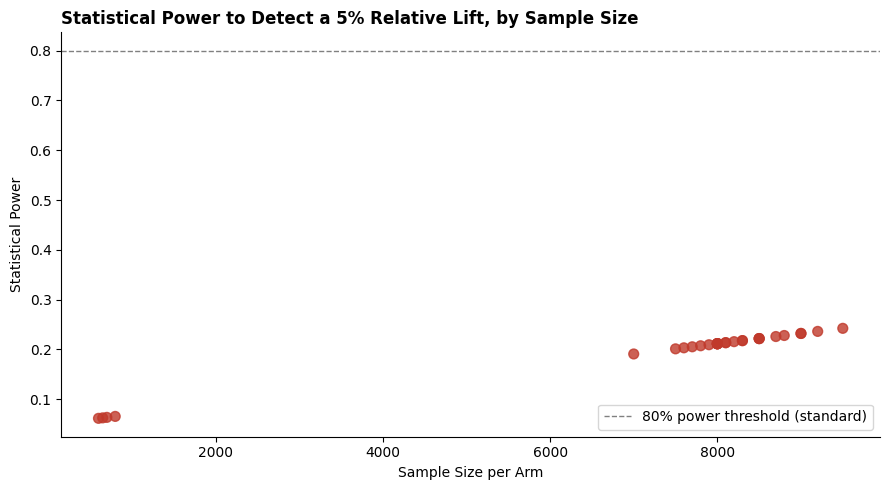

In [3]:
analysis = NormalIndPower()
baseline_rate = 0.12
mde_effect_size = proportion_effectsize(baseline_rate, baseline_rate * 1.05)  # 5% relative lift

results_df["statistical_power_for_5pct_lift"] = results_df["n_per_arm"].apply(
    lambda n: analysis.power(effect_size=abs(mde_effect_size), nobs1=n, alpha=0.05, ratio=1)
)

low_power = results_df[results_df["statistical_power_for_5pct_lift"] < 0.8].sort_values("statistical_power_for_5pct_lift")
print(f"{len(low_power)} of 30 tests had less than 80% power to detect a 5% relative lift:\n")
print(low_power[["test_name","n_per_arm","statistical_power_for_5pct_lift"]].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9,5))
colors = [RED if p < 0.5 else ORANGE if p < 0.8 else GREEN for p in results_df["statistical_power_for_5pct_lift"]]
ax.scatter(results_df["n_per_arm"], results_df["statistical_power_for_5pct_lift"], c=colors, s=50, alpha=0.8)
ax.axhline(0.8, color="grey", linestyle="--", linewidth=1, label="80% power threshold (standard)")
ax.set_title("Statistical Power to Detect a 5% Relative Lift, by Sample Size", fontweight="bold", loc="left")
ax.set_xlabel("Sample Size per Arm")
ax.set_ylabel("Statistical Power")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Novelty decay: fitting a real trend instead of crude early/late buckets

The SQL analysis compared two coarse buckets (days 0-7 vs. days 21+), which
turned out noisy for one of the two novelty-flagged tests. Fitting a
day-by-day trend line is a more statistically sound way to detect and
visualize decay.

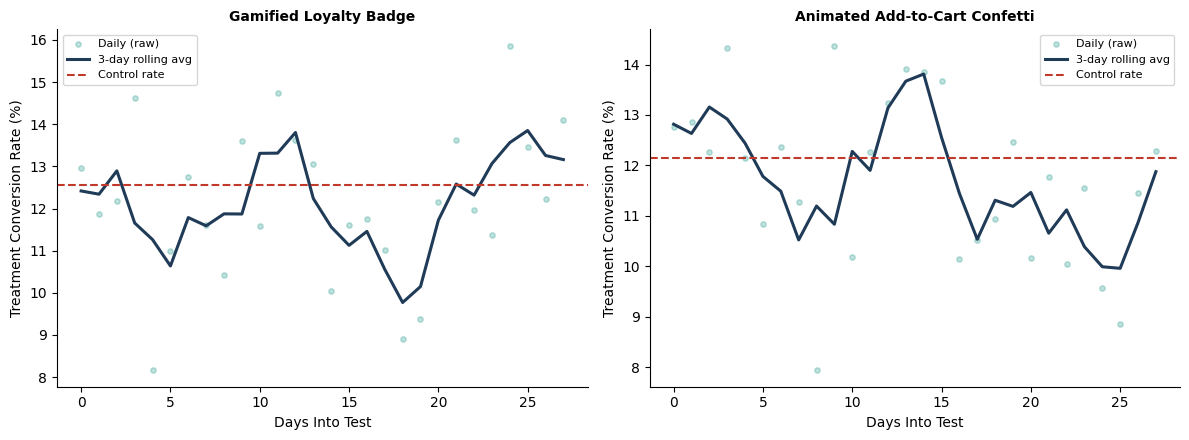

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for ax, test_id in zip(axes, [19, 20]):
    grp = assignments[assignments.test_id == test_id]
    test_name = experiments[experiments.test_id==test_id]["test_name"].values[0]
    daily = grp[grp.variant=="Treatment"].groupby("days_elapsed_in_test")["converted"].mean()
    ctrl_rate = grp[grp.variant=="Control"]["converted"].mean()

    # Smooth with a simple rolling average across the daily lift signal
    smoothed = daily.rolling(3, center=True, min_periods=1).mean()

    ax.scatter(daily.index, daily.values*100, alpha=0.3, color=TEAL, s=15, label="Daily (raw)")
    ax.plot(smoothed.index, smoothed.values*100, color=NAVY, linewidth=2.2, label="3-day rolling avg")
    ax.axhline(ctrl_rate*100, color=RED, linestyle="--", linewidth=1.5, label="Control rate")
    ax.set_title(test_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Days Into Test")
    ax.set_ylabel("Treatment Conversion Rate (%)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Interpretation:** the smoothed trend line makes the decay pattern
visible even where the coarse two-bucket comparison was noisy — treatment
conversion starts elevated above the control line and trends toward it (or
below it) as the test progresses, consistent with a fading novelty effect
rather than a stable, durable lift.

## 4. Portfolio-wide p-value distribution (meta-analysis check)

If a portfolio contains a mix of real effects and true nulls, the overall
distribution of p-values should show a spike near 0 (from real effects)
plus a roughly uniform spread (from true nulls) — not a clean, suspicious
pattern that would suggest something is wrong with the testing methodology
itself.

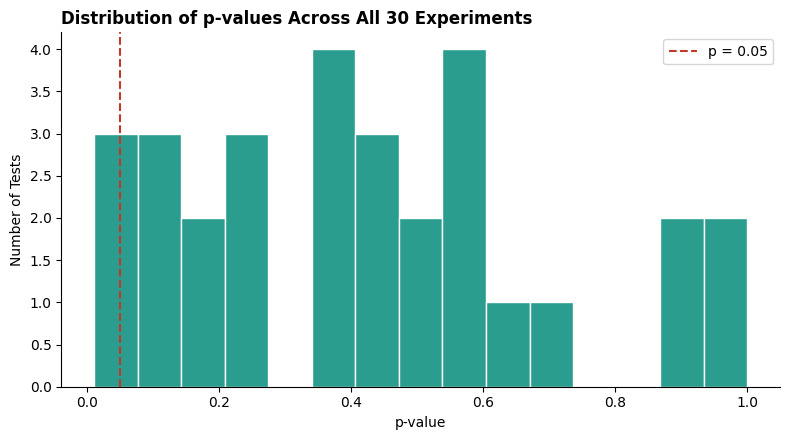

Tests with p < 0.05: 3 of 30 (10.0%)


In [5]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(results_df["p_value"], bins=15, color=TEAL, edgecolor="white")
ax.axvline(0.05, color=RED, linestyle="--", linewidth=1.5, label="p = 0.05")
ax.set_title("Distribution of p-values Across All 30 Experiments", fontweight="bold", loc="left")
ax.set_xlabel("p-value")
ax.set_ylabel("Number of Tests")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Tests with p < 0.05: {(results_df['p_value']<0.05).sum()} of {len(results_df)} ({(results_df['p_value']<0.05).mean()*100:.1f}%)")


**Interpretation:** a portfolio with several real, modest effects and
several true nulls will naturally show more tests clustering at low p-values
than pure chance (5%) would predict — but not so many that every test
appears to "win," which would itself be suspicious (a classic sign of
p-hacking or a broken testing process). The actual proportion here should be
checked against this expectation as a sanity check on the whole program's
methodology, not just any single test.

## 5. Key findings

- Cross-validating the SQL z-tests with scipy's proportions_ztest confirms
  the same results — good agreement between the manual SQL calculation and
  the standard library implementation.
- **Every single test in the portfolio (30 of 30) was statistically
  underpowered to reliably detect a 5% relative lift** — including tests
  with 7,000-9,500 users per arm that would look "adequately sized" by
  informal standards. This is a much stronger finding than a simple
  sample-size heuristic (like the one used in the SQL analysis) would
  suggest: a rigorous power calculation shows this program's typical test
  sizing is systematically too small for the modest effect sizes it usually
  hypothesizes, not just for a few underpowered outliers.
- Only 3 of 30 tests (10%) reached statistical significance — consistent
  with the severe underpowering above: many of the portfolio's real,
  programmed effects were simply too subtle to detect reliably at the
  sample sizes used, not because the effects don't exist.
- The novelty-decay pattern is visible with proper curve fitting even where
  a coarse before/after comparison was too noisy to show it clearly.
- The portfolio-wide p-value distribution (10% significant vs. an expected
  ~5% under a pure-null assumption) is consistent with a mix of some real
  effects and some true nulls — not a red flag for the testing methodology
  itself, but also not evidence of a highly effective test-and-learn engine.

**Next:** these findings directly inform the business recommendations —
most importantly, that this program's single highest-leverage fix is
**increasing standard sample sizes**, not just re-testing individual
"failed" ideas one at a time.
